# Découverte des moteurs

Ce carnet vous fait découvrir les moteurs des roues, puis vous amène à **piloter le robot** avec un vecteur vitesse et une rotation instantanée. Vous écrirez vous-même la fonction qui calcule la vitesse de chaque roue.

**Sécurité**
- Parties 1 à 7 : le robot est **sur une cale, roues en l'air**.
- Partie 8 seulement : au sol, dans un espace dégagé, avec quelqu'un à côté.
- Pour tout arrêter : menu *Kernel* → *Interrupt Kernel*. Et si votre programme cesse d'envoyer des consignes, le **chien de garde** arrête les roues en 0,5 s.

Documentation complète : `docs/moteurs.md` dans le dépôt du projet. Exécutez les cellules une par une avec **Maj + Entrée**.

## 1. Découvrir les moteurs

Chaque roue est entraînée par un moteur **Dynamixel MX-12W**. Les moteurs sont chaînés sur un même câble, le **bus série** du robot, et chacun y répond à son numéro, son **identifiant** (ID). `find_ids()` les cherche, sans rien faire bouger.

In [ ]:
from holorobot.motors import find_ids

print("moteurs trouvés :", find_ids())

## 2. Initialiser

`Motors()` ouvre le bus, retrouve les moteurs et les met en **mode roue** : en mode roue, un moteur tourne sans fin à la vitesse demandée ; dans l'autre mode, le mode articulation, il va à une position et s'y tient, comme l'articulation d'un bras robotique (partie 3).

Tant que l'objet `motors` existe, le bus est réservé à ce carnet. On le ferme à la fin (dernière cellule), ou en redémarrant le noyau.

In [ ]:
from holorobot.motors import Motors

motors = Motors()
print("identifiants :", motors.ids)
print("modèles      :", motors.models)
print("mode roue    :", motors.is_wheel_mode())
print("tension (V)  :", motors.get_voltages())
print("température  :", motors.get_temperatures())

## 3. Contrôle en position

Pour le projet, les moteurs servent de roues. Mais un Dynamixel sait aussi aller à une **position** précise et s'y tenir : c'est le **mode articulation**, celui des bras robotiques.

**Idée.** Avec la découpeuse laser ou l'imprimante 3D, deux moteurs en mode articulation font une **tourelle pan-tilt** pour la caméra : l'un la tourne à gauche et à droite (*pan*), l'autre la fait regarder en haut et en bas (*tilt*). Le robot peut alors suivre des yeux un objet reconnu dans l'image.

On l'essaie ici sur une roue, robot sur sa cale. Les positions sont en degrés, de −180 à 180 ; 0 est au milieu de la course. On donne toujours une vitesse aux mouvements, en °/s.

In [ ]:
first = motors.ids[0]
motors.set_joint_mode([first], speed=60)   # mode articulation, mouvements à 60 °/s
print("mode :", motors.modes[first], "| position :", motors.get_positions()[first], "°")

`move_to()` envoie le moteur à une position et attend qu'il y soit. Une fois arrivé, essayez de tourner la roue à la main : le moteur résiste, il **tient sa position**.

In [ ]:
motors.move_to({first: 0})                # d'abord au milieu de la course
motors.move_to({first: 90})               # puis un quart de tour, à 60 °/s
print("position :", motors.get_positions()[first], "°")
motors.move_to({first: -90}, speed=180)   # un demi-tour, trois fois plus vite
print("position :", motors.get_positions()[first], "°")
motors.move_to({first: 0})

**Un balayage**, comme une caméra qui regarde autour d'elle :

In [ ]:
for angle in (-45, 45, -45, 45, 0):
    motors.move_to({first: angle}, speed=120)

`set_positions()`, lui, donne la consigne et rend la main tout de suite : le moteur y va pendant que le programme continue, par exemple pour viser un objet que la caméra suit.

In [ ]:
import time

motors.set_positions({first: 30}, speed=60)
for _ in range(6):
    print(f"en route : {motors.get_positions()[first]:6.1f}°")
    time.sleep(0.1)

On repasse enfin en **mode roue** pour la suite : le moteur repart à l'arrêt.

In [ ]:
motors.set_wheel_mode()
print("mode roue :", motors.is_wheel_mode())

## 4. Faire tourner une roue

Les vitesses sont en **degrés par seconde** (°/s). Une vitesse positive fait tourner la roue dans le sens inverse des aiguilles d'une montre, vue du côté de la roue.

`run(vitesses, duration)` fait tourner les roues pendant `duration` secondes, puis les arrête. Les vitesses sont données dans un dictionnaire `{identifiant: vitesse}`.

In [ ]:
first = motors.ids[0]
motors.run({first: 90}, duration=2)   # 90 °/s pendant 2 s : un quart de tour par seconde

**Le chien de garde.** Une consigne envoyée avec `set_speeds()` ne vaut que 0,5 s : passé ce délai sans nouvelle consigne, toutes les roues s'arrêtent. C'est ce qui arrête le robot si votre programme plante ou si vous fermez le navigateur. Vérifiez-le :

In [ ]:
import time

motors.set_speeds({first: 90})
time.sleep(2)
print("vitesse mesurée après 2 s :", motors.get_speeds()[first], "°/s")
print("arrêts par le chien de garde :", motors.watchdog_stops)

## 5. Faire tourner plusieurs roues en même temps

Il suffit de mettre plusieurs moteurs dans le dictionnaire.

In [ ]:
motors.run({i: 90 for i in motors.ids}, duration=2)

**Question.** Toutes les vitesses sont positives. Si le robot était au sol, irait-il tout droit ? Regardez dans quel sens tournent les roues de gauche et celles de droite.

Pour commander en continu, renvoyez la consigne souvent, au moins 4 fois par seconde, dans une boucle :

In [ ]:
end = time.monotonic() + 3
while time.monotonic() < end:
    motors.set_speeds({i: 120 for i in motors.ids})   # renvoyée toutes les 0,05 s : le chien de garde est content
    time.sleep(0.05)
measured = motors.get_speeds()
motors.stop()
print("vitesses mesurées juste avant l'arrêt (°/s) :", measured)

## 6. Identifier les roues de votre robot

La cellule suivante fait tourner chaque moteur, l'un après l'autre, avec une vitesse positive. Pour chacun, notez :
- **quelle roue** tourne (avant gauche, avant droite, arrière gauche, arrière droite ; ou roue 1, 2, 3 sur un robot à 3 roues, numérotées comme sur le schéma de la partie 7) ;
- **son sens** : si le dessus de la roue part vers l'avant du robot, la roue ferait avancer le robot.

In [ ]:
for i in motors.ids:
    print(f"moteur {i} : quelle roue ? quel sens ?")
    motors.run({i: 90}, duration=2)
    time.sleep(1)

Remplissez maintenant le tableau `WHEELS` : pour chaque roue, l'identifiant de son moteur et son **sens**, +1 ou −1 :
- robot à 4 roues mecanum : +1 si, avec une vitesse positive, le dessus de la roue part vers l'avant du robot (la roue ferait avancer le robot), −1 sinon ;
- robot à 3 roues holonomes : +1 si le dessus de la roue part dans le sens de $\vec d_i$ (schéma de la partie 7) : la roue ferait tourner le robot dans le sens inverse des aiguilles d'une montre, vu de dessus ; −1 sinon.

In [ ]:
# Robot à 4 roues mecanum : nom de la roue -> (identifiant du moteur, sens)
WHEELS = {
    "avant_gauche": (None, None),
    "avant_droite": (None, None),
    "arriere_gauche": (None, None),
    "arriere_droite": (None, None),
}

# Robot à 3 roues holonomes : utilisez plutôt ce tableau
# WHEELS = {"roue_1": (None, None), "roue_2": (None, None), "roue_3": (None, None)}

In [ ]:
def check_wheels(wheels):
    ids = [motor for motor, _ in wheels.values()]
    assert None not in ids, "il manque des identifiants"
    assert sorted(ids) == sorted(motors.ids), f"les identifiants doivent être exactement {motors.ids}"
    assert all(sign in (1, -1) for _, sign in wheels.values()), "le sens doit valoir +1 ou -1"
    print("tableau des roues : ok")


check_wheels(WHEELS)

**Vérification.** Avec les sens du tableau, toutes les roues doivent maintenant rouler « vers l'avant » (ou selon leur $\vec d_i$ sur un robot à 3 roues). Si l'une tourne à l'envers, corrigez son sens.

In [ ]:
motors.run({motor: sign * 90 for motor, sign in WHEELS.values()}, duration=2)

## 7. Du mouvement du robot aux vitesses des roues

### Le repère du robot

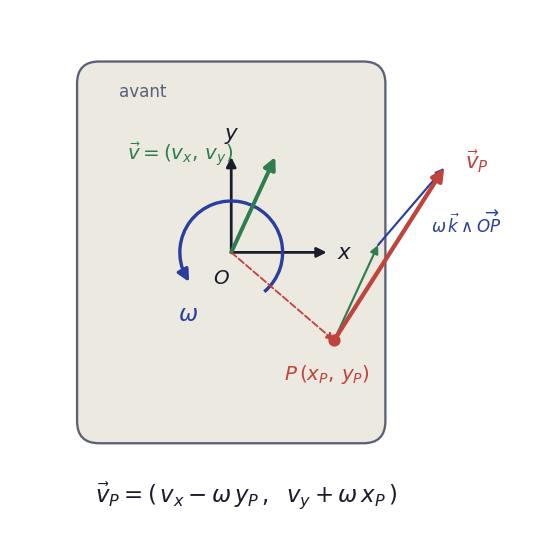

Chaque robot est différent : c'est vous qui le concevez. On décrit son mouvement dans son propre repère, centré en $O$ : **x vers la droite**, **y vers l'avant**, l'avant que vous avez choisi. Un robot holonome peut se déplacer dans n'importe quelle direction tout en tournant. À chaque instant, son mouvement est donné par :
- un **vecteur vitesse** $\vec v = (v_x, v_y)$, en m/s ;
- une **rotation instantanée** $\omega$, en rad/s, positive dans le sens inverse des aiguilles d'une montre vu de dessus.

Un point $P$ du robot, de coordonnées $(x_P, y_P)$, a alors pour vitesse :

$$\vec v_P = (\,v_x - \omega\,y_P\,,\; v_y + \omega\,x_P\,)$$

C'est la vitesse du **centre de chaque roue** qui va nous intéresser. Mesurez d'abord votre robot :

In [ ]:
import numpy as np

R_WHEEL = None   # rayon d'une roue, en m (diamètre / 2)
LX = None        # robot à 4 roues : demi-distance entre les centres des roues gauche et droite (selon x), en m
LY = None        # robot à 4 roues : demi-distance entre les axes avant et arrière (selon y), en m
R_BASE = None    # robot à 3 roues : distance du centre du robot au centre de chaque roue, en m

### Roues mecanum (robot à 4 roues)

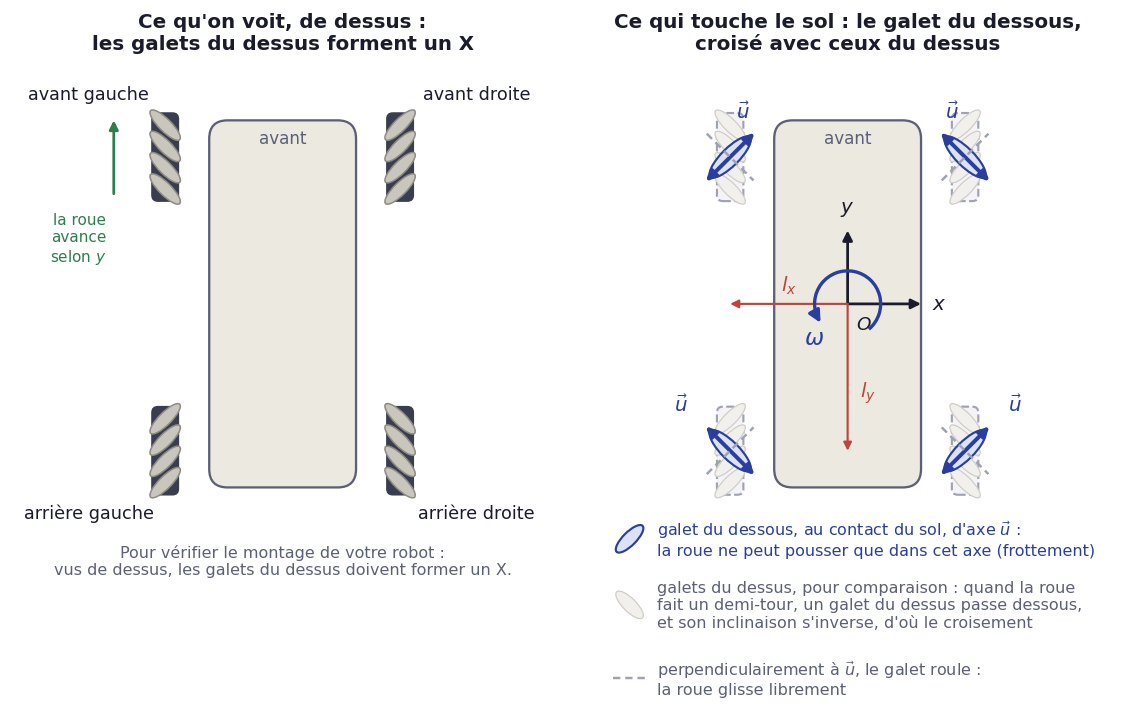

Une roue mecanum roule vers l'avant comme une roue ordinaire, mais sa jante porte des **galets** libres, inclinés à 45°. Ce qui compte, c'est le galet **au contact du sol**, d'axe $\vec u_i$ :
- **dans l'axe du galet**, selon $\vec u_i$, le galet ne peut pas rouler : il frotte sur le sol. C'est la seule direction dans laquelle la roue peut **pousser** le robot (force de traction, due au frottement) ;
- **perpendiculairement à** $\vec u_i$, le galet roule librement : la roue **glisse** sans résister.

Attention : le galet qui touche le sol est celui **de l'autre côté de la roue**, en dessous. Vu de dessus, il est croisé avec les galets du dessus, ceux que vous voyez (schéma de gauche) : quand la roue fait un demi-tour, un galet du dessus passe dessous et son inclinaison s'inverse. Sur le schéma de droite, il est en bleu, et les galets du dessus en gris clair.

**La condition de roulement.** Le point du galet qui touche le sol ne doit pas glisser dans l'axe du galet. Sa vitesse par rapport au sol est la somme de trois termes :
1. la vitesse du centre de la roue, $\vec v_{P_i}$ ;
2. l'effet de la rotation de la roue : quand elle tourne vers l'avant à $\omega_i$ (rad/s), le bas de la roue recule de $r\,\omega_i$ par rapport à son centre, soit $-r\,\omega_i\,\vec y$ ;
3. l'effet de la rotation du galet sur son axe : n'importe quelle vitesse, mais toujours perpendiculaire à $\vec u_i$.

Le troisième terme absorbe tout ce qui est perpendiculaire à $\vec u_i$. Selon $\vec u_i$, rien ne compense : la somme des deux premiers termes ne doit avoir aucune composante selon $\vec u_i$.

$$(\vec v_{P_i} - r\,\omega_i\,\vec y)\cdot \vec u_i = 0 \quad\Longrightarrow\quad \omega_i = \frac{\vec v_{P_i}\cdot\vec u_i}{r\,(\vec y\cdot\vec u_i)}$$

**À vous :**
1. Vérifiez que les galets du dessus de votre robot dessinent un **X** vu de dessus, comme sur le schéma de gauche. S'ils dessinent un losange (montage en O), échangez les roues avant et arrière de chaque côté : en O, les roues poussent presque vers le centre du robot, qui tourne mal.
2. Écrivez la position $P_i$ de chaque roue : $(\pm l_x, \pm l_y)$.
3. Calculez la vitesse $\vec v_{P_i}$ du centre de chaque roue.
4. Lisez $\vec u_i$ pour chaque roue sur le schéma de droite. Par exemple, pour la roue avant gauche, $\vec u = (1, 1)/\sqrt2$.
5. Déduisez $\omega_i$ pour chaque roue, puis complétez la fonction ci-dessous.

In [ ]:
def mecanum_wheel_speeds(vx, vy, omega, r=None, lx=None, ly=None):
    """Vitesses de rotation des 4 roues mecanum, en rad/s (positif = la roue fait avancer le robot).

    vx, vy : vecteur vitesse du robot (x vers la droite, y vers l'avant), en m/s ;
    omega : rotation instantanée, en rad/s.
    """
    r = R_WHEEL if r is None else r
    lx = LX if lx is None else lx
    ly = LY if ly is None else ly
    assert None not in (r, lx, ly), "renseignez R_WHEEL, LX et LY : les mesures du robot"
    # À vous : remplacez les 0.0 par vos formules
    return {
        "avant_gauche": 0.0,
        "avant_droite": 0.0,
        "arriere_gauche": 0.0,
        "arriere_droite": 0.0,
    }

Testez votre fonction : la cellule suivante l'essaie sur des mouvements simples, avec des dimensions de test (roues de 3 cm de rayon, $l_x$ = 12 cm, $l_y$ = 10 cm).

In [ ]:
def check(f, names, cases, **dims):
    """Compare f à des résultats attendus ; vérifie aussi qu'un mouvement combiné est la somme des mouvements."""
    def show(speeds):
        return ", ".join(f"{n} {speeds[n]:+.3f}" if isinstance(speeds.get(n), (int, float)) else f"{n} ?" for n in names)

    all_ok = True
    parts = []
    for label, args, expected in cases:
        got = f(*args, **dims)
        assert isinstance(got, dict), "la fonction doit renvoyer un dictionnaire {nom de la roue: vitesse}"
        parts.append(got)
        ok = all(abs(got.get(n, np.nan) - expected[n]) < 1e-6 for n in names)
        all_ok &= ok
        print(("✓ " if ok else "✗ ") + label + ("" if ok else f"\n    attendu : {show(expected)}\n    obtenu  : {show(got)}"))
    combined = f(*[sum(c[1][k] for c in cases) for k in range(3)], **dims)
    ok = all(abs(combined.get(n, np.nan) - sum(p.get(n, np.nan) for p in parts)) < 1e-6 for n in names)
    all_ok &= ok
    print(("✓ " if ok else "✗ ") + "mouvement combiné = somme des mouvements simples")
    print("\nBravo, tout est juste !" if all_ok else "\nIl reste des erreurs : reprenez le calcul.")


MECANUM = ("avant_gauche", "avant_droite", "arriere_gauche", "arriere_droite")
check(mecanum_wheel_speeds, MECANUM, [
    ("avancer à 0,3 m/s : toutes les roues à v/r", (0, 0.3, 0), dict.fromkeys(MECANUM, 10.0)),
    ("aller vers la droite à 0,3 m/s", (0.3, 0, 0),
     {"avant_gauche": 10.0, "avant_droite": -10.0, "arriere_gauche": -10.0, "arriere_droite": 10.0}),
    ("tourner à 1 rad/s, dans le sens inverse des aiguilles d'une montre", (0, 0, 1.0),
     {"avant_gauche": -22 / 3, "avant_droite": 22 / 3, "arriere_gauche": -22 / 3, "arriere_droite": 22 / 3}),
], r=0.03, lx=0.12, ly=0.10)

### Roues holonomes (robot à 3 roues)

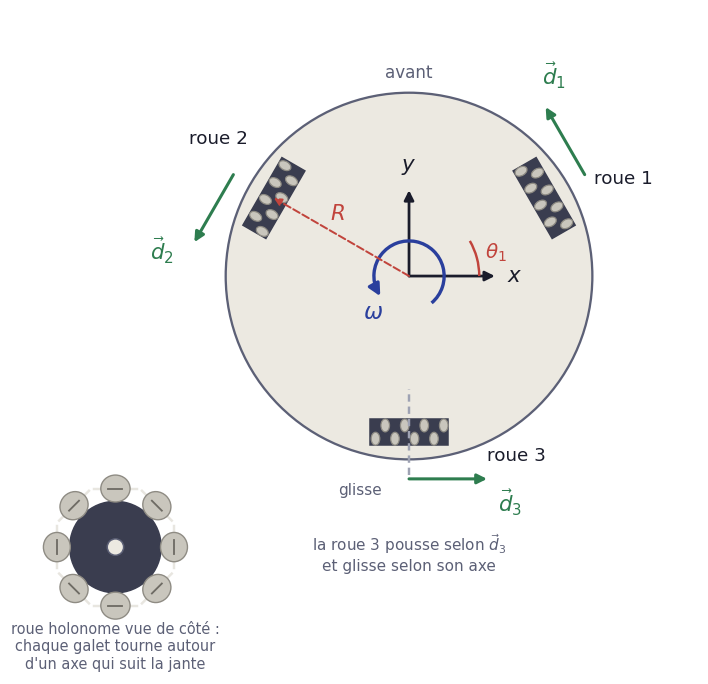

Une roue holonome porte sur sa jante des galets libres dont l'axe suit la jante. C'est le même principe que la roue mecanum : elle **pousse** dans l'axe de son galet au contact du sol, c'est-à-dire dans la direction où elle roule, $\vec d_i$, et elle **glisse** librement perpendiculairement, dans la direction de son axe. Seule compte donc la composante de la vitesse de son centre selon $\vec d_i$ :

$$\omega_i = \frac{\vec d_i \cdot \vec v_{P_i}}{r}$$

Les roues sont à la distance $R$ du centre, aux angles $\theta_i$ comptés depuis l'axe $x$, dans le sens inverse des aiguilles d'une montre. Sur le schéma, $\theta_1 = 30°$, $\theta_2 = 150°$ et $\theta_3 = 270°$ : adaptez à votre robot.

**À vous :**
1. Écrivez la position $P_i = (R\cos\theta_i, R\sin\theta_i)$ et la direction $\vec d_i = (-\sin\theta_i, \cos\theta_i)$ de chaque roue.
2. Calculez $\vec v_{P_i}$, puis $\vec d_i \cdot \vec v_{P_i}$ : vous devriez trouver une formule très simple.
3. Complétez la fonction ci-dessous.

In [ ]:
THETAS = (30, 150, 270)   # angles des roues 1, 2 et 3, en degrés : adaptez à votre robot


def omni_wheel_speeds(vx, vy, omega, r=None, R=None, thetas=THETAS):
    """Vitesses de rotation des 3 roues holonomes, en rad/s (positif = la roue pousse selon son d_i).

    vx, vy : vecteur vitesse du robot (x vers la droite, y vers l'avant), en m/s ;
    omega : rotation instantanée, en rad/s.
    """
    r = R_WHEEL if r is None else r
    R = R_BASE if R is None else R
    assert None not in (r, R), "renseignez R_WHEEL et R_BASE : les mesures du robot"
    # À vous : remplacez les 0.0 par votre formule (np.radians convertit des degrés en radians)
    return {f"roue_{k}": 0.0 for k in (1, 2, 3)}

In [ ]:
OMNI = ("roue_1", "roue_2", "roue_3")
s3 = np.sqrt(3) / 2
check(omni_wheel_speeds, OMNI, [
    ("avancer à 0,3 m/s", (0, 0.3, 0), {"roue_1": 10 * s3, "roue_2": -10 * s3, "roue_3": 0.0}),
    ("aller vers la droite à 0,3 m/s", (0.3, 0, 0), {"roue_1": -5.0, "roue_2": -5.0, "roue_3": 10.0}),
    ("tourner à 1 rad/s : toutes les roues à R·ω/r", (0, 0, 1.0), dict.fromkeys(OMNI, 10 / 3)),
], r=0.03, R=0.10, thetas=(30, 150, 270))

## 8. Piloter le robot

Il ne reste qu'à assembler : votre fonction donne la vitesse de chaque roue en rad/s ; on la convertit en °/s, on applique le sens du moteur, et on l'envoie au bon identifiant grâce au tableau `WHEELS`.

In [ ]:
def to_motor_speeds(wheel_speeds):
    """Vitesses des roues (rad/s) -> consignes des moteurs (°/s), avec le sens de chaque moteur."""
    return {WHEELS[name][0]: WHEELS[name][1] * np.degrees(w) for name, w in wheel_speeds.items()}


def drive(vx, vy, omega, duration):
    """Déplace le robot : vecteur vitesse (vx, vy) en m/s, x vers la droite et y vers l'avant,
    et rotation omega en rad/s, pendant duration secondes."""
    speeds = mecanum_wheel_speeds(vx, vy, omega)   # robot à 3 roues : omni_wheel_speeds(vx, vy, omega)
    motors.run(to_motor_speeds(speeds), duration)

**D'abord sur la cale.** Le robot est toujours roues en l'air : regardez si les roues tournent comme prévu.
- Pour avancer, toutes les roues doivent rouler vers l'avant.
- Pour aller à droite, comparez avec vos résultats de la partie 7.

In [ ]:
drive(0, 0.1, 0, 2)     # avancer
time.sleep(1)
drive(0.1, 0, 0, 2)     # aller à droite
time.sleep(1)
drive(0, 0, 0.5, 2)     # tourner sur place

**Puis au sol**, dans un espace dégagé, avec quelqu'un à côté. Mesurez ce que fait vraiment le robot : la distance parcourue, l'angle tourné. Sur un sol lisse, les roues patinent un peu.

In [ ]:
drive(0, 0.1, 0, 2)                 # avancer de 20 cm
time.sleep(1)
drive(0.1, 0, 0, 2)                 # glisser de 20 cm vers la droite
time.sleep(1)
drive(0, 0, np.pi / 2 / 3, 3)     # tourner d'un quart de tour en 3 s

**Pour aller plus loin**
- Faites parcourir un carré au robot, sans qu'il tourne sur lui-même, puis en restant toujours face à sa direction de déplacement.
- Faites-le avancer en tournant autour d'un point fixe.
- Combinez avec le lidar : arrêtez le robot si un obstacle est à moins de 30 cm devant lui.

## Fermer

Libérez le bus pour les autres programmes : roues arrêtées, couple coupé.

In [ ]:
motors.close()